# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Daniel Andres Barona Sandoval, 2026

# 04_modelo
Plantilla para el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno representa la culminación del proceso, donde aplicamos técnicas de machine learning para crear modelos predictivos o descriptivos basados en los datos preparados.

**Propósito:** Desarrollar, entrenar y validar modelos de machine learning que respondan a los objetivos del proyecto.

**Tareas habituales:**
- Selección de características (feature selection)
- Ingeniería de características (feature engineering)
- División de datos en conjuntos de entrenamiento y prueba
- Selección y entrenamiento de modelos
- Optimización de hiperparámetros
- Validación cruzada
- Evaluación de métricas de rendimiento
- Documentación del proceso de modelado
- Guardado y versionado de modelos
- Análisis de importancia de características

In [11]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
import os
warnings.filterwarnings("ignore")
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
import getpass
import ipywidgets as widgets
from IPython.display import display

In [2]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.3 MB/s eta 0:00:00


In [4]:
try:
    import pmdarima as pm; HAS_PMDARIMA = True
except ImportError:
    HAS_PMDARIMA = False
    print("pmdarima no instalado; se usará búsqueda manual por AIC.")

In [6]:
!git clone https://github.com/daniel-barona/proyecto_ciencia_datos

Cloning into 'proyecto_ciencia_datos'...
remote: Enumerating objects: 410, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 410 (delta 75), reused 38 (delta 35), pack-reused 314 (from 3)
Receiving objects: 100% (410/410), 625.24 MiB | 29.91 MiB/s, done.
Resolving deltas: 100% (212/212), done.
Updating files: 100% (56/56), done.


In [9]:
folder_path = Path("/content/proyecto_ciencia_datos/data/trusted")
files = list(folder_path.glob("*.xlsx"))
print(f"Archivos encontrados: {len(files)}")
for file in files:
    print(file.name)

Archivos encontrados: 1
SIPSA_2013_2026_trusted.xlsx


# DISEÑO DEL ALGORITMO

**La idea del algoritmo es la siguiente:**

1. El usuario debe seleccinar el departamento que desee estudiar, (puede escoger los departamentos disponibles, bogota esta incluido en la lista por el datset y Colombia tambien va a estar disponible si el usuario desea hacer un estudio a nivel nacional)
2. Despues de escoger el departamento (excluyendo bogota y colombia) el usuario podra escoger entre de las ciudades de ese departamento que pertenecen y que tienen activo centros de venta mayorista para poductos alimentarios.
3. Una vez escogido se le debe mostrar los productos disponibles en la ciudad.
4. el usuario escoge el producto a investigar.
5. Alli se empieza a realizar la estadistica, la idea es hacer selecion de todas las soliitudes realizadas por el usuario y realizar un problema de serie de tiempo
- Opcion A: usar los promedios mensuales por año (solicitud del cliente)
- Opcion B: recoletar todos los datos obtenidos de la solicitud de usuario por año
6. Debe realizar el analisis, presentar las graficas, presentar promedio de mes mensual actual (hasta junio) y dar la probabilidad del precio del producto en la cuidad seleccionada.


In [10]:
trusted_dir = "/content/proyecto_ciencia_datos/data/trusted"
df = pd.read_excel(f"{trusted_dir}/SIPSA_2013_2026_trusted.xlsx")
df

,fecha,grupo,producto,mercado,departamento,codigo_departamento,municipio,codigo_municipio,precio_promedio_kg,circulacion
0,2013-01-01,carnes,alas de pollo con costillar,"barranquilla, barranquillita",atlantico,8,barranquilla,8001,3073.0,si
1,2013-01-01,carnes,alas de pollo con costillar,"bogota, d.c., frigorifico guadalupe","bogota, d.c.",11,"bogota, d.c.",11001,2560.0,si
2,2013-01-01,carnes,alas de pollo con costillar,"cartagena, bazurto",bolivar,13,cartagena de indias,13001,3429.0,si
3,2013-01-01,carnes,alas de pollo con costillar,"ibague, plaza la 21",tolima,73,ibague,73001,4307.0,si
4,2013-01-01,carnes,alas de pollo con costillar,"medellin, plaza minorista ""jose maria villa""",antioquia,5,medellin,5001,3717.0,si
...,...,...,...,...,...,...,...,...,...,...
749048,2026-06-01,frutas,manzana royal gala importada,"neiva, surabastos",huila,41,neiva,41001,8706.0,si
749049,2026-06-01,frutas,manzana royal gala importada,"monteria, mercado del sur",cordoba,23,monteria,23001,8573.0,si
749050,2026-06-01,frutas,manzana royal gala importada,"medellin, central mayorista de antioquia",antioquia,5,medellin,5001,7517.0,si
749051,2026-06-01,frutas,naranja valencia,"valledupar, mercabastos",cesar,20,valledupar,20001,2494.0,si


## Entrenar el Modelo

In [12]:
departamentos_2026 = sorted(
    df.loc[df["fecha"].dt.year == 2026, "departamento"]
      .dropna()
      .unique()
)
departamentos_2026

['antioquia',
 'arauca',
 'atlantico',
 'bogota, d.c.',
 'bolivar',
 'boyaca',
 'caldas',
 'caqueta',
 'casanare',
 'cauca',
 'cesar',
 'cordoba',
 'cundinamarca',
 'huila',
 'magdalena',
 'meta',
 'narino',
 'norte de santander',
 'quindio',
 'risaralda',
 'santander',
 'sucre',
 'tolima',
 'valle del cauca']

In [15]:
departamentos = ['colombia'] + departamentos_2026

In [16]:
dropdown_departamento = widgets.Dropdown(
    options=departamentos,
    description='Departamento:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
display(dropdown_departamento)

Dropdown(description='Departamento:', layout=Layout(width='400px'), options=('colombia', 'antioquia', 'arauca'…

In [17]:
departamento = dropdown_departamento.value
print("Departamento seleccionado:", departamento)

Departamento seleccionado: valle del cauca


In [18]:
if departamento.lower() not in ['colombia', 'bogota, d.c.']:
    municipios = sorted(
        df[
            (df["departamento"] == departamento) &
            (df["fecha"].dt.year == 2026)
        ]["municipio"]
        .dropna()
        .unique()
        .tolist()
    )

    dropdown_municipio = widgets.Dropdown(
        options=municipios,
        description='Municipio:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )

    display(dropdown_municipio)

else:
    print("No es necesario seleccionar un municipio.")

Dropdown(description='Municipio:', layout=Layout(width='400px'), options=('buenaventura', 'cali', 'cartago', '…

In [19]:
if departamento.lower() not in ['colombia', 'bogota, d.c.']:
    municipio = dropdown_municipio.value
    print("Municipio seleccionado:", municipio)

Municipio seleccionado: cali


In [20]:
if departamento.lower() == 'colombia':

    mercados = sorted(
        df[df["fecha"].dt.year == 2026]["mercado"]
        .dropna()
        .unique()
        .tolist()
    )

elif departamento.lower() == 'bogota, d.c.':

    mercados = sorted(
        df[
            (df["departamento"] == departamento) &
            (df["fecha"].dt.year == 2026)
        ]["mercado"]
        .dropna()
        .unique()
        .tolist()
    )

else:

    municipio = dropdown_municipio.value

    mercados = sorted(
        df[
            (df["municipio"] == municipio) &
            (df["fecha"].dt.year == 2026)
        ]["mercado"]
        .dropna()
        .unique()
        .tolist()
    )

dropdown_mercado = widgets.Dropdown(
    options=mercados,
    description='Mercado:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

display(dropdown_mercado)

Dropdown(description='Mercado:', layout=Layout(width='400px'), options=('cali, cavasa', 'cali, galeria alameda…

In [21]:
mercado = dropdown_mercado.value
print("Mercado seleccionado:", mercado)

Mercado seleccionado: cali, santa elena


In [22]:
mercado = dropdown_mercado.value

productos = sorted(
    df[
        (df["mercado"] == mercado) &
        (df["fecha"].dt.year == 2026)
    ]["producto"]
    .dropna()
    .unique()
    .tolist()
)

dropdown_producto = widgets.Dropdown(
    options=productos,
    description='Producto:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

display(dropdown_producto)

Dropdown(description='Producto:', layout=Layout(width='400px'), options=('aceite vegetal mezcla', 'aguacate ch…

In [23]:
producto = dropdown_producto.value
print("Producto seleccionado:", producto)

Producto seleccionado: maracuya


## Inicio del Modelo - Hacer Pruebas

# Fase 1: creacion de la serie

In [25]:
def preparar_serie(df, mercado, producto):
    serie = (
        df[
            (df['mercado'] == mercado) &
            (df['producto'] == producto)
        ][['fecha', 'precio_promedio_kg']]
        .copy()
    )
    serie = serie.sort_values('fecha')
    serie.set_index('fecha', inplace=True)

    serie.rename(
        columns={'precio_promedio_kg': 'precio'},
        inplace=True,
    )
    # Si hay varios registros en la misma fecha (p.ej. municipios), promediamos
    serie = serie.groupby(serie.index).mean()
    # Frecuencia mensual + relleno de huecos
    serie = serie.asfreq('MS').interpolate('linear').ffill().bfill()
    return serie['precio']
y = preparar_serie(df, mercado, producto)
y

,precio
fecha,
2013-01-01,1109.0
2013-02-01,1795.0
2013-03-01,2638.0
2013-04-01,1518.0
2013-05-01,1081.0
...,...
2026-02-01,4700.0
2026-03-01,6317.0
2026-04-01,4546.0


## Fase 1b — Verificación del tamaño de la serie
Antes de modelar, comprueba que la serie tenga suficientes observaciones. Reglas prácticas para SARIMA con estacionalidad mensual (m=12):

- **< 24 meses**: insuficiente — no se puede estimar componente estacional.
- **24–35 meses**: mínimo aceptable — modelo poco confiable, evita SARIMA (usa ARIMA no estacional).
- **36–47 meses**: aceptable — SARIMA viable pero con incertidumbre alta.
- **48–71 meses**: bueno — recomendado (≥ 4 ciclos estacionales).
- **≥ 72 meses**: óptimo (≥ 6 ciclos).

In [26]:
def verificar_registros(y, m=12, verbose=True):
    """Evalúa si la serie tiene suficientes registros para ARIMA/SARIMA.
    Devuelve dict con: n, ciclos, nivel, recomendacion, seasonal_ok, apto.
    """
    n = int(len(y))
    n_valid = int(y.notna().sum())
    ciclos = n / m if m else 0

    if n < 24:
        nivel = 'INSUFICIENTE'
        seasonal_ok = False; apto = False
        rec = 'No hay datos suficientes. Se necesitan al menos 24 meses (2 ciclos) para modelar estacionalidad.'
    elif n < 36:
        nivel = 'MINIMO'
        seasonal_ok = False; apto = True
        rec = 'Usar ARIMA no estacional (seasonal=False) o Holt-Winters. SARIMA aún no es confiable.'
    elif n < 48:
        nivel = 'ACEPTABLE'
        seasonal_ok = True; apto = True
        rec = 'SARIMA viable pero con incertidumbre alta. Usa walk-forward y valida MASE < 1.'
    elif n < 72:
        nivel = 'BUENO'
        seasonal_ok = True; apto = True
        rec = 'Cantidad recomendada. SARIMA debería capturar bien la estacionalidad.'
    else:
        nivel = 'OPTIMO'
        seasonal_ok = True; apto = True
        rec = 'Serie larga: puedes probar SARIMA con estacionalidad completa y regresores de Fourier.'

    info = {
        'n': n, 'n_validos': n_valid, 'ciclos_estacionales': round(ciclos,2),
        'nivel': nivel, 'seasonal_ok': seasonal_ok, 'apto': apto,
        'recomendacion': rec,
    }
    if verbose:
        print(f"Registros totales : {n}")
        print(f"Registros válidos : {n_valid}")
        print(f"Ciclos (m={m})     : {ciclos:.2f}")
        print(f"Nivel             : {nivel}")
        print(f"SARIMA estacional : {'sí' if seasonal_ok else 'no'}")
        print(f"Recomendación     : {rec}")
        if not apto:
            print('\n⚠️  No continúes con el modelo hasta conseguir más datos.')
    return info

# Uso:
info = verificar_registros(y, m=12)
if not info['apto']:
    raise ValueError('Serie insuficiente para modelar.')
seasonal = info['seasonal_ok']  # pásalo a ajustar_sarima(..., seasonal=seasonal)


Registros totales : 162
Registros válidos : 162
Ciclos (m=12)     : 13.50
Nivel             : OPTIMO
SARIMA estacional : sí
Recomendación     : Serie larga: puedes probar SARIMA con estacionalidad completa y regresores de Fourier.


#Fase 3: EDA express y especifico

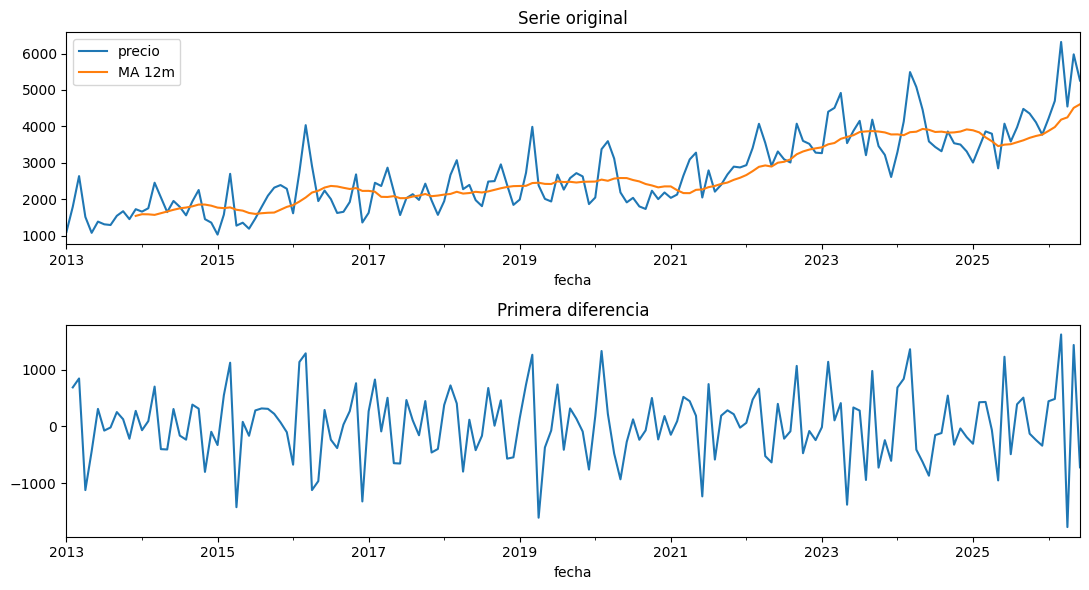

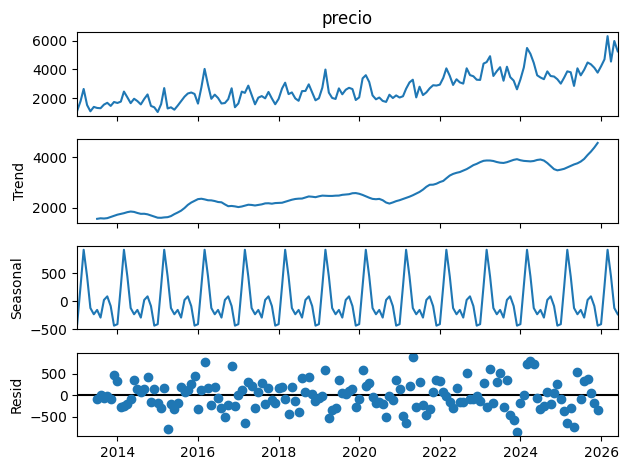

In [28]:
def eda(y):
    fig, ax = plt.subplots(2,1,figsize=(11,6))
    y.plot(ax=ax[0], title="Serie original")
    y.rolling(12).mean().plot(ax=ax[0], label="MA 12m"); ax[0].legend()
    y.diff().plot(ax=ax[1], title="Primera diferencia")
    plt.tight_layout(); plt.show()
    seasonal_decompose(y, model="additive", period=12).plot(); plt.show()
eda(y)

## Fase 3 — Estacionariedad y diferenciación

In [30]:
def test_estacionariedad(y):
    adf = adfuller(y.dropna()); kps = kpss(y.dropna(), regression="c", nlags="auto")
    print(f"ADF  p={adf[1]:.4f} (H0: no estacionaria)")
    print(f"KPSS p={kps[1]:.4f} (H0: estacionaria)")

def sugerir_diferencias(y, m=12):
    d=0; yt=y.copy()
    while adfuller(yt.dropna())[1]>0.05 and d<2:
        yt=yt.diff(); d+=1
    D=0
    if (yt.dropna().autocorr(lag=m) or 0)>0.3 and D<1:
        yt=yt.diff(m); D+=1
    print(f"Sugerencia: d={d}, D={D}"); return d,D
test_estacionariedad(y); d,D = sugerir_diferencias(y)

ADF  p=0.9785 (H0: no estacionaria)
KPSS p=0.0100 (H0: estacionaria)
Sugerencia: d=1, D=1


## Fase 4 — Identificación (ACF/PACF)

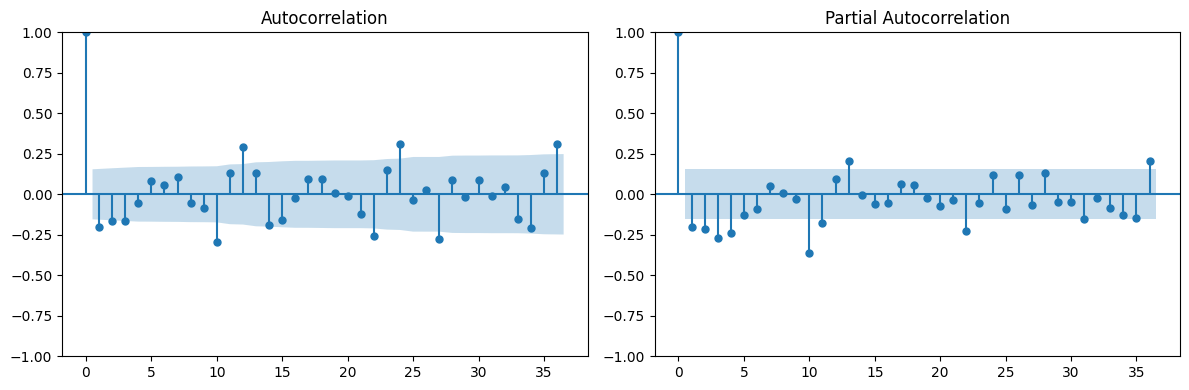

In [31]:
def plot_acf_pacf(y, lags=36):
    fig, ax = plt.subplots(1,2,figsize=(12,4))
    plot_acf(y.dropna(), lags=lags, ax=ax[0])
    plot_pacf(y.dropna(), lags=lags, ax=ax[1], method="ywm")
    plt.tight_layout(); plt.show()
plot_acf_pacf(y.diff().dropna())

## Fase 5 — Estimación (auto_arima / grid AIC)

In [34]:
def ajustar_sarima(y, m=12, seasonal=True, use_log=True):
    """Ajusta SARIMA. Si use_log=True, modela log(y) para estabilizar varianza."""
    y_mod = np.log(y) if use_log else y
    if HAS_PMDARIMA:
        model = pm.auto_arima(
            y_mod, seasonal=seasonal, m=m,
            start_p=0, start_q=0, max_p=3, max_q=3,
            start_P=0, start_Q=0, max_P=2, max_Q=2,
            d=None, D=1 if seasonal else 0,
            stepwise=True, trace=True,
            information_criterion="aicc",
            error_action="ignore", suppress_warnings=True,
        )
        print(model.summary())
        return model.order, model.seasonal_order, use_log
    import itertools
    best = (None, np.inf, None)
    for p, d, q in itertools.product(range(3), range(2), range(3)):
        for P, D, Q in itertools.product(range(2), range(2), range(2)):
            try:
                res = SARIMAX(y_mod, order=(p,d,q), seasonal_order=(P,D,Q,m),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                if res.aic < best[1]:
                    best = ((p,d,q), res.aic, (P,D,Q,m))
            except Exception:
                pass
    print("Mejor:", best)
    return best[0], best[2], use_log


In [35]:
order, seasonal_order, use_log = ajustar_sarima(y, m=12, seasonal=True, use_log=True)
print('order:', order, 'seasonal_order:', seasonal_order, 'use_log:', use_log)

Performing stepwise search to minimize aicc
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AICC=23.309, Time=0.42 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AICC=-50.989, Time=2.55 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AICC=inf, Time=2.83 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AICC=37.935, Time=0.10 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AICC=-16.144, Time=0.33 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AICC=-75.139, Time=1.38 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AICC=-81.788, Time=4.05 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AICC=-82.883, Time=1.91 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AICC=-84.932, Time=0.48 sec
 ARIMA(1,0,0)(0,1,2)[12] intercept   : AICC=-82.900, Time=1.12 sec
 ARIMA(1,0,0)(1,1,2)[12] intercept   : AICC=-80.657, Time=1.41 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AICC=inf, Time=0.39 sec
 ARIMA(2,0,0)(0,1,1)[12] intercept   : AICC=-87.216, Time=0.63 sec
 ARIMA(2,0,0)(0,1,0)[12] intercept   : AICC=-21.571, Time=0.10 sec
 ARIMA(2,0,0)(1,1,1)[12] int

## Fase 6 — Diagnóstico de residuos

                                      SARIMAX Results                                       
Dep. Variable:                               precio   No. Observations:                  162
Model:             SARIMAX(3, 0, 0)x(0, 1, [1], 12)   Log Likelihood               -1038.773
Date:                              Sat, 25 Jul 2026   AIC                           2087.546
Time:                                      21:02:28   BIC                           2102.146
Sample:                                  01-01-2013   HQIC                          2093.479
                                       - 06-01-2026                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4049      0.074      5.505      0.000       0.261       0.549
ar.L2          0.37

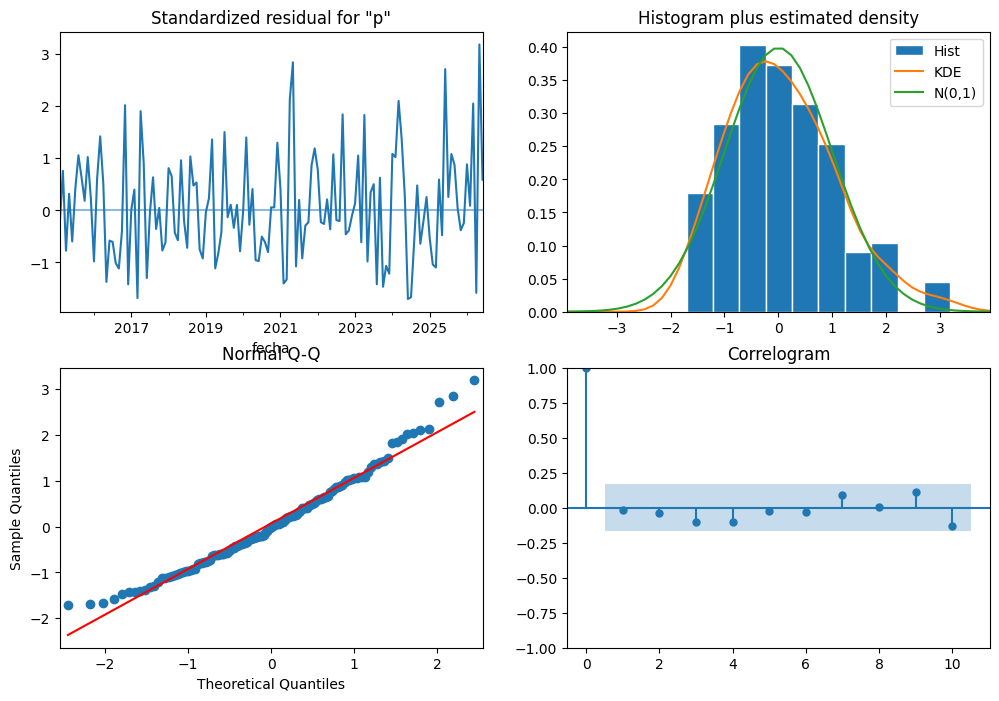

      lb_stat  lb_pvalue
12  16.780133   0.158057
24  25.891061   0.358716


In [36]:
def diagnosticar(y, order, seasonal_order):
    res = SARIMAX(y, order=order, seasonal_order=seasonal_order,
        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    print(res.summary()); res.plot_diagnostics(figsize=(12,8)); plt.show()
    from statsmodels.stats.diagnostic import acorr_ljungbox
    print(acorr_ljungbox(res.resid, lags=[12,24], return_df=True))
    return res
fit = diagnosticar(y, order, seasonal_order)

## Fase 7 — Validación (backtest walk-forward + sMAPE / MASE)

MAE=550.348  RMSE=766.387  MAPE=11.26%  sMAPE=12.20%  MASE=0.001


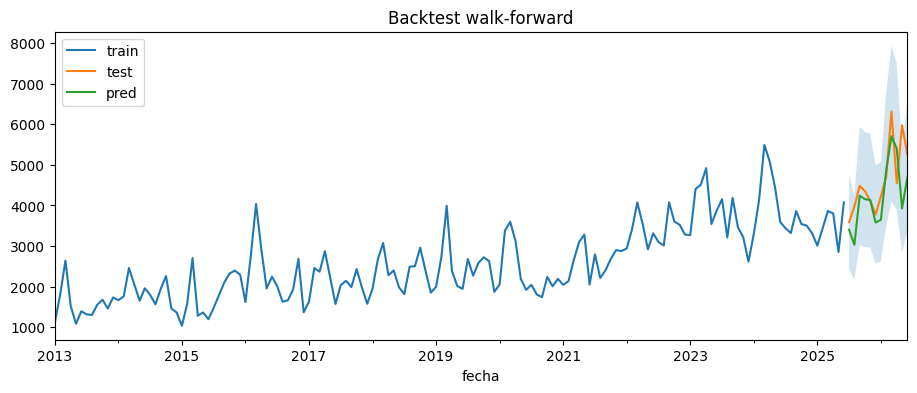

In [37]:
def _smape(a, f):
    a, f = np.asarray(a), np.asarray(f)
    return np.mean(2*np.abs(f-a)/(np.abs(a)+np.abs(f)+1e-9))*100

def _mase(train, test, pred, m=12):
    train = np.asarray(train); test = np.asarray(test); pred = np.asarray(pred)
    d = np.mean(np.abs(np.diff(train, n=m))) if len(train) > m else np.mean(np.abs(np.diff(train)))
    return np.mean(np.abs(test - pred)) / (d + 1e-9)

def backtest(y, order, seasonal_order, h=12, use_log=True, walk_forward=True):
    """Backtest walk-forward paso a paso. Refita en cada paso (más realista)."""
    y_mod = np.log(y) if use_log else y
    train, test = y_mod.iloc[:-h], y_mod.iloc[-h:]
    preds, lowers, uppers = [], [], []

    if walk_forward:
        history = train.copy()
        for t in test.index:
            res = SARIMAX(history, order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            fc = res.get_forecast(steps=1)
            preds.append(fc.predicted_mean.iloc[0])
            ci_ = fc.conf_int().iloc[0]
            lowers.append(ci_.iloc[0]); uppers.append(ci_.iloc[1])
            history = pd.concat([history, test.loc[[t]]])
        pred = pd.Series(preds, index=test.index)
        ci = pd.DataFrame({"lower": lowers, "upper": uppers}, index=test.index)
    else:
        res = SARIMAX(train, order=order, seasonal_order=seasonal_order,
            enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        fc = res.get_forecast(steps=h)
        pred = fc.predicted_mean
        ci = fc.conf_int()
        ci.columns = ["lower", "upper"]

    # Revertimos escala si usamos log (con corrección de sesgo)
    if use_log:
        sigma2 = np.var(train.values - pred.reindex(train.index).fillna(train).values) if False else 0.0
        pred_orig = np.exp(pred + sigma2/2)
        ci_orig = np.exp(ci)
        test_orig = np.exp(test)
        train_orig = np.exp(train)
    else:
        pred_orig, ci_orig, test_orig, train_orig = pred, ci, test, train

    mae = mean_absolute_error(test_orig, pred_orig)
    rmse = np.sqrt(mean_squared_error(test_orig, pred_orig))
    mape = np.mean(np.abs((test_orig - pred_orig)/test_orig))*100
    smape = _smape(test_orig, pred_orig)
    mase = _mase(train_orig, test_orig, pred_orig, m=seasonal_order[-1] if seasonal_order else 12)
    print(f"MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%  sMAPE={smape:.2f}%  MASE={mase:.3f}")

    plt.figure(figsize=(11,4))
    train_orig.plot(label="train"); test_orig.plot(label="test"); pred_orig.plot(label="pred")
    plt.fill_between(ci_orig.index, ci_orig.iloc[:,0], ci_orig.iloc[:,1], alpha=.2)
    plt.legend(); plt.title("Backtest walk-forward"); plt.show()

    return {"mae":mae, "rmse":rmse, "mape":mape, "smape":smape, "mase":mase,
            "pred":pred_orig, "ci":ci_orig}

metrics = backtest(y, order, seasonal_order, h=12, use_log=use_log)


## Fase 8 — Pronóstico final

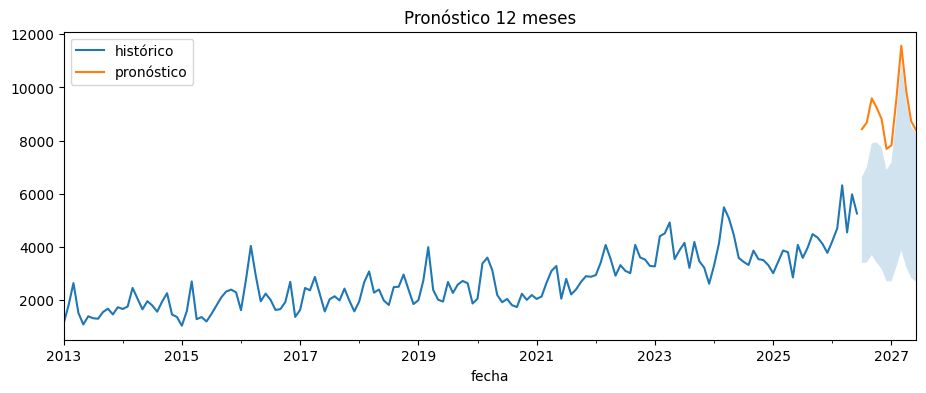

In [39]:
def pronosticar(y, order, seasonal_order, steps=12, use_log=True):
    y_mod = np.log(y) if use_log else y
    res = SARIMAX(y_mod, order=order, seasonal_order=seasonal_order,
        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    fc = res.get_forecast(steps=steps)
    pred = fc.predicted_mean; ci = fc.conf_int()

    if use_log:
        # Corrección de sesgo al revertir el log: E[exp(x)] = exp(mu + sigma^2/2)
        sigma2 = float(res.mse) if hasattr(res, "mse") else 0.0
        pred = np.exp(pred + sigma2/2)
        ci = np.exp(ci)

    plt.figure(figsize=(11,4))
    y.plot(label="histórico"); pred.plot(label="pronóstico")
    plt.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], alpha=.2)
    plt.legend(); plt.title(f"Pronóstico {steps} meses"); plt.show()
    return res, pred, ci

fit_final, pred, ci = pronosticar(y, order, seasonal_order, steps=12, use_log=use_log)


## Fase 9 — Persistencia y monitoreo

In [42]:
def guardar(fit, mercado, producto, path="modelos"):
    import os; os.makedirs(path, exist_ok=True)
    fname = f"{path}/sarima_{mercado}_{producto}.pkl".replace(" ","_")
    joblib.dump(fit, fname); print("Guardado en", fname); return fname
guardar(fit_final, mercado, producto)
#Monitoreo: comparar real vs pred mes a mes; alertar si |error|>umbral.

Guardado en modelos/sarima_cali,_santa_elena_maracuya.pkl


'modelos/sarima_cali,_santa_elena_maracuya.pkl'

## Resumen de resultados

Performing stepwise search to minimize aicc
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AICC=23.309, Time=0.07 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AICC=-50.989, Time=0.54 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AICC=inf, Time=1.26 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AICC=37.935, Time=0.07 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AICC=-16.144, Time=0.19 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AICC=-75.139, Time=1.68 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AICC=-81.788, Time=2.47 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AICC=-82.883, Time=0.67 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AICC=-84.932, Time=0.31 sec
 ARIMA(1,0,0)(0,1,2)[12] intercept   : AICC=-82.900, Time=0.97 sec
 ARIMA(1,0,0)(1,1,2)[12] intercept   : AICC=-80.657, Time=1.21 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AICC=inf, Time=0.39 sec
 ARIMA(2,0,0)(0,1,1)[12] intercept   : AICC=-87.216, Time=0.63 sec
 ARIMA(2,0,0)(0,1,0)[12] intercept   : AICC=-21.571, Time=0.09 sec
 ARIMA(2,0,0)(1,1,1)[12] int

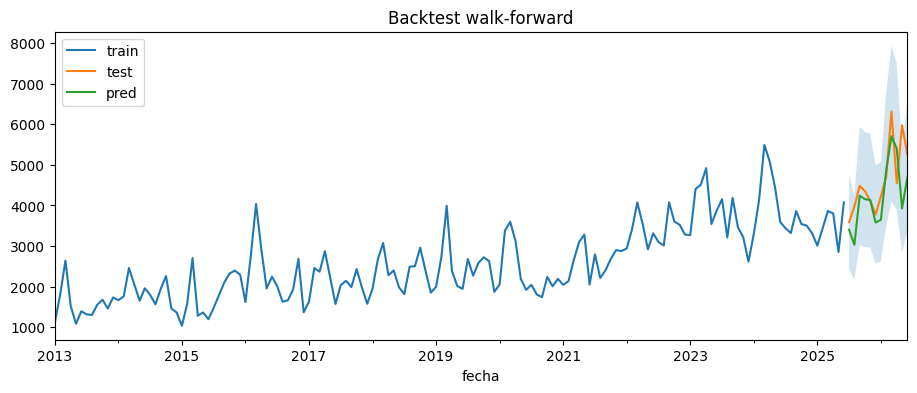

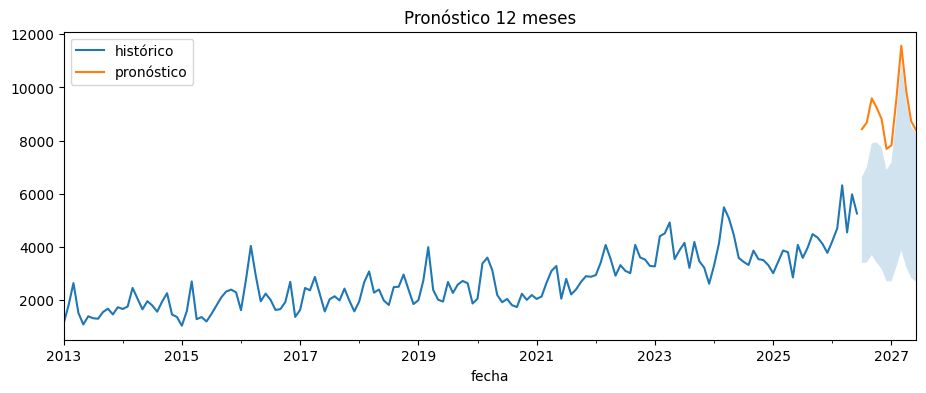

RESUMEN DE RESULTADOS
Métricas backtest:
   MAE   = 550.348
   RMSE  = 766.387
   MAPE  = 11.26%
   sMAPE = 12.20%
   MASE  = 0.001   (<1 = mejor que naive estacional)
-------------------------------------------------------
Promedio último mes observado (2026-06): 5,258.00
Pronóstico mes siguiente     (2026-07): 8,430.83
   Intervalo 95%: [3,394.11 ; 6,628.91]


In [43]:
def resumen_resultados(y, metrics, pred, ci):
    ultimo_mes = y.index.max()
    valor_ultimo_mes = float(y.loc[y.index == ultimo_mes].mean())

    fecha_siguiente = pred.index[0]
    valor_siguiente = float(pred.iloc[0])
    li, ls = float(ci.iloc[0, 0]), float(ci.iloc[0, 1])

    print("=" * 55)
    print("RESUMEN DE RESULTADOS")
    print("=" * 55)
    print("Métricas backtest:")
    print(f"   MAE   = {metrics['mae']:.3f}")
    print(f"   RMSE  = {metrics['rmse']:.3f}")
    print(f"   MAPE  = {metrics['mape']:.2f}%")
    if 'smape' in metrics: print(f"   sMAPE = {metrics['smape']:.2f}%")
    if 'mase'  in metrics: print(f"   MASE  = {metrics['mase']:.3f}   (<1 = mejor que naive estacional)")
    print("-" * 55)
    print(f"Promedio último mes observado ({ultimo_mes:%Y-%m}): {valor_ultimo_mes:,.2f}")
    print(f"Pronóstico mes siguiente     ({fecha_siguiente:%Y-%m}): {valor_siguiente:,.2f}")
    print(f"   Intervalo 95%: [{li:,.2f} ; {ls:,.2f}]")
    print("=" * 55)

    return {
        "mae": metrics["mae"], "rmse": metrics["rmse"], "mape": metrics["mape"],
        "smape": metrics.get("smape"), "mase": metrics.get("mase"),
        "ultimo_mes": ultimo_mes, "valor_ultimo_mes": valor_ultimo_mes,
        "fecha_pronostico": fecha_siguiente, "valor_pronostico": valor_siguiente,
        "ic_inf": li, "ic_sup": ls,
    }

# Uso:
order, seasonal_order, use_log = ajustar_sarima(y, m=12, seasonal=True, use_log=True)
metrics = backtest(y, order, seasonal_order, h=12, use_log=use_log)
fit_final, pred, ci = pronosticar(y, order, seasonal_order, steps=12, use_log=use_log)
resumen = resumen_resultados(y, metrics, pred, ci)


**Último paso**: Guardar el Modelo para ser utilizado en el **Producto de Datos**

**Producto de Datos**:

- Aplicación Web, formulario que pide los datos y entrega la estimación/predicción/etc.
- Aplicación Móvil
- Tablero o _Dashboard_: Dash, Streamlit, Flask, PowerBI, Tableau, Qlik, Looker
- API: permite hacer las consultas para "embeberlas" en una aplicación de usuario
